# Thematische Analyse
Kongruenz nach Thema, Abstimmungstyp und Zeit.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("../data/processed/swissvotes_processed.csv")
df['datum'] = pd.to_datetime(df['datum'])
df['year'] = df['datum'].dt.year
df['decade'] = (df['year'] // 10) * 10

## Hilfsfunktion: Kongruenz pro Gruppe

In [3]:
PARTIES = {
    'SVP': 'p-svp',
    'SP':  'p-sps',
    'FDP': 'p-fdp',
    'CVP': 'p-mitte',
    'GPS': 'p-gps',
    'BR':  'br-pos',
}

def kongruenz_gruppe(df, pos_col, group_col, min_n=10):
    """
    Berechnet die Kongruenz (Anteil Stimmende, die der Empfehlung folgten)
    pro Gruppe (z.B. Dekade, Thema, Abstimmungstyp).

    Gibt ein DataFrame zurück mit Spalten: [group_col, 'kongruenz', 'n']
    """
    temp = df[[pos_col, 'volkja-proz', group_col]].copy()
    temp[pos_col] = pd.to_numeric(temp[pos_col], errors='coerce')
    temp = temp[temp[pos_col].isin([1.0, 2.0]) & temp['volkja-proz'].notna()]

    ja_anteil = temp['volkja-proz'] / 100
    ist_ja = (temp[pos_col] == 1.0)
    temp['zustimmung'] = np.where(ist_ja, ja_anteil, 1 - ja_anteil)

    result = (
        temp.groupby(group_col)['zustimmung']
        .agg(kongruenz='mean', n='count')
        .reset_index()
    )
    return result[result['n'] >= min_n]

## 1. Kongruenz über Zeit (nach Dekade)

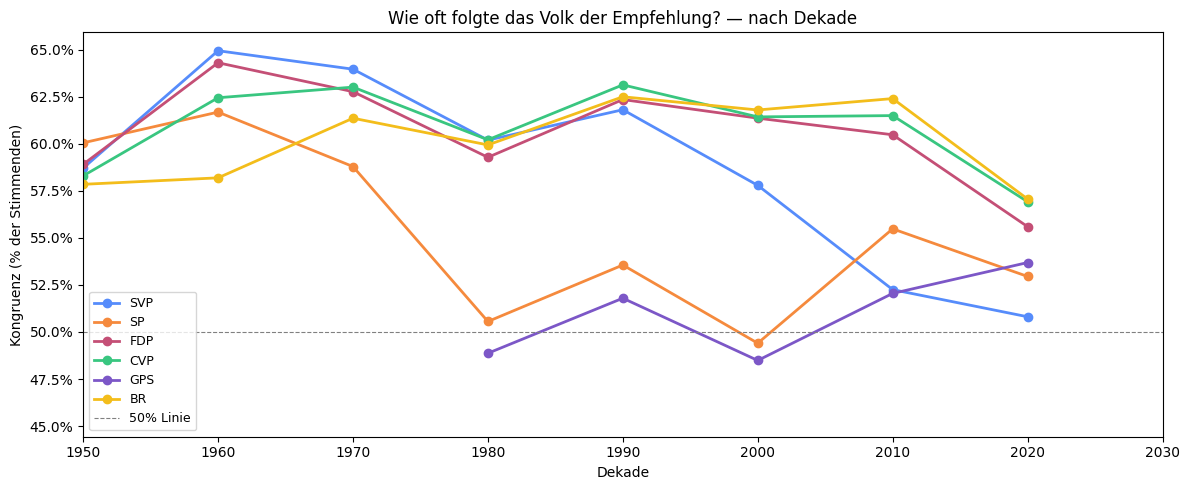

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, col in PARTIES.items():
    res = kongruenz_gruppe(df, col, 'decade')
    ax.plot(res['decade'], res['kongruenz'] * 100, marker='o', label=label, linewidth=2)

ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% Linie')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Dekade')
ax.set_ylabel('Kongruenz (% der Stimmenden)')
ax.set_title('Wie oft folgte das Volk der Empfehlung? — nach Dekade')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(1950, 2030)   # vor 1950 zu wenig Daten für viele Parteien
plt.tight_layout()
plt.show()

## 2. Kongruenz nach Abstimmungstyp (`rechtsform_name`)

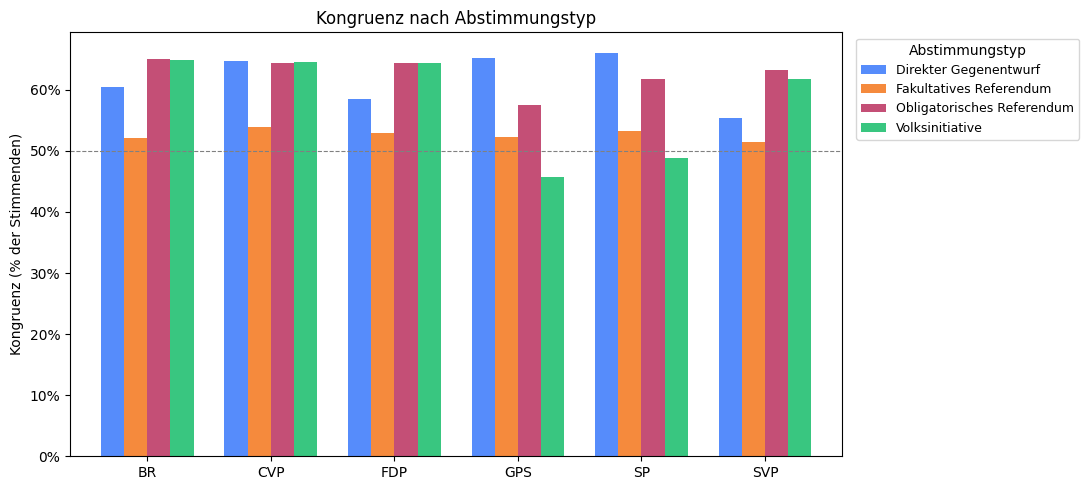

In [5]:
rows = []
for label, col in PARTIES.items():
    res = kongruenz_gruppe(df, col, 'rechtsform_name')
    res['partei'] = label
    rows.append(res)

df_rechtsform = pd.concat(rows, ignore_index=True)

# Pivot für Heatmap-artigen Barplot
pivot = df_rechtsform.pivot(index='partei', columns='rechtsform_name', values='kongruenz') * 100

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind='bar', ax=ax, width=0.75)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('')
ax.set_ylabel('Kongruenz (% der Stimmenden)')
ax.set_title('Kongruenz nach Abstimmungstyp')
ax.legend(title='Abstimmungstyp', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Kongruenz nach Thema (`hauptgruppe`)

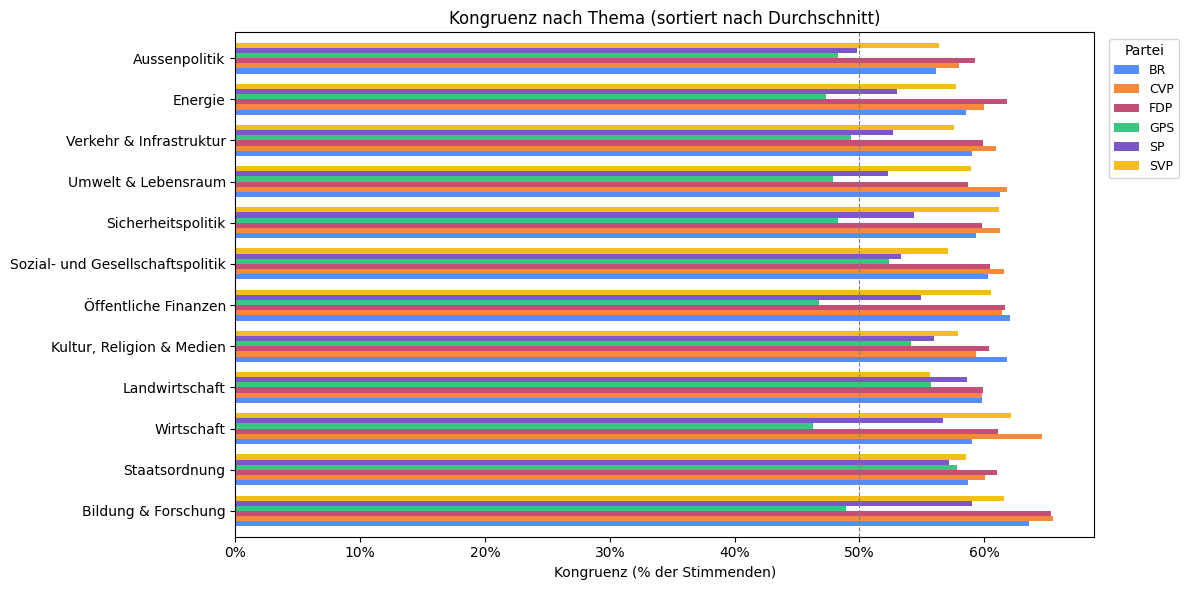

In [6]:
rows = []
for label, col in PARTIES.items():
    res = kongruenz_gruppe(df, col, 'hauptgruppe')
    res['partei'] = label
    rows.append(res)

df_thema = pd.concat(rows, ignore_index=True)

# Mittlere Kongruenz pro Thema (über alle Parteien) als Sortierkriterium
thema_order = (
    df_thema.groupby('hauptgruppe')['kongruenz'].mean()
    .sort_values(ascending=False).index
)

pivot_thema = (
    df_thema.pivot(index='hauptgruppe', columns='partei', values='kongruenz') * 100
).reindex(thema_order)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_thema.plot(kind='barh', ax=ax, width=0.75)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Kongruenz (% der Stimmenden)')
ax.set_ylabel('')
ax.set_title('Kongruenz nach Thema (sortiert nach Durchschnitt)')
ax.legend(title='Partei', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Übersichtstabelle

In [7]:
rows = []
for label, col in PARTIES.items():
    for group_col, group_name in [('rechtsform_name', 'Typ'), ('hauptgruppe', 'Thema'), ('decade', 'Dekade')]:
        res = kongruenz_gruppe(df, col, group_col)
        res['Partei'] = label
        res['Gruppierung'] = group_name
        res = res.rename(columns={group_col: 'Gruppe', 'kongruenz': 'Kongruenz', 'n': 'N'})
        rows.append(res)

df_all = pd.concat(rows, ignore_index=True)
df_all['Kongruenz'] = (df_all['Kongruenz'] * 100).round(1)

# Extremfälle anzeigen
print("=== Höchste Kongruenz ===")
print(df_all.nlargest(10, 'Kongruenz')[['Partei', 'Gruppierung', 'Gruppe', 'Kongruenz', 'N']].to_string(index=False))
print()
print("=== Niedrigste Kongruenz ===")
print(df_all.nsmallest(10, 'Kongruenz')[['Partei', 'Gruppierung', 'Gruppe', 'Kongruenz', 'N']].to_string(index=False))

=== Höchste Kongruenz ===
Partei Gruppierung                     Gruppe  Kongruenz   N
    SP         Typ      Direkter Gegenentwurf       66.1  38
   CVP       Thema        Bildung & Forschung       65.5  23
   FDP       Thema        Bildung & Forschung       65.4  24
   GPS         Typ      Direkter Gegenentwurf       65.3  20
    BR         Typ Obligatorisches Referendum       65.0  88
   SVP      Dekade                       1960       64.9  24
    BR         Typ            Volksinitiative       64.9 234
   CVP         Typ      Direkter Gegenentwurf       64.8  30
   CVP         Typ            Volksinitiative       64.6 222
   CVP       Thema                 Wirtschaft       64.6  55

=== Niedrigste Kongruenz ===
Partei Gruppierung               Gruppe  Kongruenz   N
    BR      Dekade                 1890       45.4  10
   GPS         Typ      Volksinitiative       45.8 154
   GPS       Thema           Wirtschaft       46.3  18
   GPS       Thema Öffentliche Finanzen       46.7  2